# EDA

STEP 1  Import Libraries
STEP 2  Load Processed Dataset
STEP 3  Dataset Overview
STEP 4  Create Target Variable

--------------- Portfolio Analysis ----------------

STEP 5  Portfolio Overview KPIs
STEP 6  Portfolio Composition

--------------- Borrower Analysis ----------------

STEP 7  Loan Grade Analysis
STEP 8  Sub Grade Analysis
STEP 9  Interest Rate Analysis
STEP 10 Annual Income Analysis
STEP 11 Employment Length Analysis
STEP 12 Home Ownership Analysis
STEP 13 Loan Purpose Analysis
STEP 14 State-wise Analysis

--------------- Credit Risk Analysis ----------------

STEP 15 Loan Term Analysis
STEP 16 DTI Analysis
STEP 17 Revolving Utilization Analysis
STEP 18 FICO Score Analysis
STEP 19 Loan Amount Analysis

--------------- Statistical Analysis ----------------

STEP 20 Correlation Analysis
STEP 21 Outlier Detection
STEP 22 Hypothesis Generation

--------------- Business Insights ----------------

STEP 23 Risk Segmentation
STEP 24 Key Business Insights
STEP 25 Save Dataset

In [ ]:
# STEP 1: Import Required Libraries

# -----------------------------
# Data Manipulation
# -----------------------------
import pandas as pd
import numpy as np

# -----------------------------
# Data Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# Statistical Analysis
# -----------------------------
from scipy import stats

# -----------------------------
# Ignore Warnings
# -----------------------------
import warnings
warnings.filterwarnings("ignore")

# -----------------------------
# Display Settings
# -----------------------------
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# -----------------------------
# Plot Settings
# -----------------------------
plt.style.use("ggplot")

# Increase default figure size
plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


| Library    | Why do we need it?      |
| ---------- | ----------------------- |
| Pandas     | Data Cleaning, Analysis |
| NumPy      | Numerical Calculations  |
| Matplotlib | Basic Charts            |
| Seaborn    | Statistical Charts      |
| SciPy      | Hypothesis Testing      |


In [33]:
# STEP 2: Load Cleaned Dataset

loan_df = pd.read_csv("../data/processed/loan_cleaned.csv",
                      parse_dates=["issue_d"])
print("Dataset Loaded Successfully ✅")
loan_df.head()

Dataset Loaded Successfully ✅


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,purpose,dti,revol_util,fico_range_low,fico_range_high,issue_d,addr_state,loan_status
0,3600.0,3600.0,36,13.99,123.03,C,C4,10+ YEARS,MORTGAGE,55000.0,DEBT_CONSOLIDATION,5.91,29.7,675.0,679.0,2015-12-01,PA,FULLY PAID
1,24700.0,24700.0,36,11.99,820.28,C,C1,10+ YEARS,MORTGAGE,65000.0,SMALL_BUSINESS,16.06,19.2,715.0,719.0,2015-12-01,SD,FULLY PAID
2,20000.0,20000.0,60,10.78,432.66,B,B4,10+ YEARS,MORTGAGE,63000.0,HOME_IMPROVEMENT,10.78,56.2,695.0,699.0,2015-12-01,IL,FULLY PAID
3,35000.0,35000.0,60,14.85,829.90,C,C5,10+ YEARS,MORTGAGE,110000.0,DEBT_CONSOLIDATION,17.06,11.6,785.0,789.0,2015-12-01,NJ,CURRENT
4,10400.0,10400.0,60,22.45,289.91,F,F1,3 YEARS,MORTGAGE,104433.0,MAJOR_PURCHASE,25.37,64.5,695.0,699.0,2015-12-01,PA,FULLY PAID


In [34]:
# STEP 3: Dataset Overview

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(loan_df.shape)

print("\n")

print("="*60)
print("DATA TYPES")
print("="*60)

loan_df.info()

print("\n")

print("="*60)
print("NUMERICAL SUMMARY")
print("="*60)

loan_df.describe().T

DATASET SHAPE
(2260668, 18)


DATA TYPES
<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 18 columns):
 #   Column           Dtype         
---  ------           -----         
 0   loan_amnt        float64       
 1   funded_amnt      float64       
 2   term             int64         
 3   int_rate         float64       
 4   installment      float64       
 5   grade            str           
 6   sub_grade        str           
 7   emp_length       str           
 8   home_ownership   str           
 9   annual_inc       float64       
 10  purpose          str           
 11  dti              float64       
 12  revol_util       float64       
 13  fico_range_low   float64       
 14  fico_range_high  float64       
 15  issue_d          datetime64[us]
 16  addr_state       str           
 17  loan_status      str           
dtypes: datetime64[us](1), float64(9), int64(1), str(7)
memory usage: 310.5 MB


NUMERICAL SUMMARY


,count,mean,min,25%,50%,75%,max,std
loan_amnt,2260668.0,15046.931228,500.0,8000.0,12900.0,20000.0,40000.0,9190.245488
funded_amnt,2260668.0,15041.664057,500.0,8000.0,12875.0,20000.0,40000.0,9188.413022
term,2260668.0,42.910319,36.0,36.0,36.0,60.0,60.0,10.867161
int_rate,2260668.0,13.092829,5.31,9.49,12.62,15.99,30.99,4.832138
installment,2260668.0,445.806823,4.93,251.65,377.99,593.32,1719.83,267.173535
annual_inc,2260668.0,77992.405698,0.0,46000.0,65000.0,93000.0,110000000.0,112696.101198
dti,2260668.0,18.823452,-1.0,11.9,17.84,24.48,999.0,14.177986
revol_util,2260668.0,50.337666,0.0,31.5,50.3,69.3,892.3,24.703222
fico_range_low,2260668.0,698.588205,610.0,675.0,690.0,715.0,845.0,33.010376
fico_range_high,2260668.0,702.5884,614.0,679.0,694.0,719.0,850.0,33.011245


In [35]:
# View categorical summary
loan_df.describe(include="object").T

,count,unique,top,freq
grade,2260668,7,B,663557
sub_grade,2260668,35,C1,145903
emp_length,2260668,11,10+ YEARS,894912
home_ownership,2260668,6,MORTGAGE,1111450
purpose,2260668,14,DEBT_CONSOLIDATION,1277877
addr_state,2260668,51,CA,314533
loan_status,2260668,9,FULLY PAID,1076751


In [36]:
# Check Missing Values

loan_df.isnull().sum()

loan_amnt          0
funded_amnt        0
term               0
int_rate           0
installment        0
grade              0
sub_grade          0
emp_length         0
home_ownership     0
annual_inc         0
purpose            0
dti                0
revol_util         0
fico_range_low     0
fico_range_high    0
issue_d            0
addr_state         0
loan_status        0
dtype: int64

In [37]:
# Check duplicate Records

int(loan_df.duplicated().sum())

0

In [38]:
# Dataset Memory Usage ( tell us how much RAM each column consumes)

loan_df.memory_usage(deep=True)

Index                    132
loan_amnt           18085344
funded_amnt         18085344
term                18085344
int_rate            18085344
installment         18085344
grade              113033400
sub_grade          115294068
emp_length         128428817
home_ownership     124007333
annual_inc          18085344
purpose            144213609
dti                 18085344
revol_util          18085344
fico_range_low      18085344
fico_range_high     18085344
issue_d             18085344
addr_state         115294068
loan_status        131367980
dtype: int64

In [39]:
# STEP 4: Create Target Variable (VERY IMPORTANT)

loan_df["loan_status"].value_counts()

loan_status
FULLY PAID                                             1076751
CURRENT                                                 878317
CHARGED OFF                                             268559
LATE (31-120 DAYS)                                       21467
IN GRACE PERIOD                                           8436
LATE (16-30 DAYS)                                         4349
DOES NOT MEET THE CREDIT POLICY. STATUS:FULLY PAID        1988
DOES NOT MEET THE CREDIT POLICY. STATUS:CHARGED OFF        761
DEFAULT                                                     40
Name: count, dtype: int64

Business Logic
For a Credit Risk Model

Fully Paid

→ Good Loan

→ 0

Charged Off

Late (31-120 days)

Late (16-30 days)

Default

→ Bad Loan

→ 1

In [40]:
# STEP 4: Create Target Variable

# Keep only completed loans
loan_df = loan_df[
    loan_df["loan_status"].isin([
        "FULLY PAID",
        "CHARGED OFF",
        "DEFAULT",
        "LATE (31-120 DAYS)",
        "LATE (16-30 DAYS)"
    ])
]


# Create Binary Target Variable
loan_df["default_flag"] = np.where(
    loan_df["loan_status"] == "FULLY PAID",
    0,
    1
)

loan_df["default_flag"].value_counts()

default_flag
0    1076751
1     294415
Name: count, dtype: int64

In [41]:
loan_df[["loan_status","default_flag"]].head(15)

,loan_status,default_flag
0,FULLY PAID,0
1,FULLY PAID,0
2,FULLY PAID,0
4,FULLY PAID,0
5,FULLY PAID,0
6,FULLY PAID,0
7,FULLY PAID,0
8,FULLY PAID,0
9,FULLY PAID,0
12,FULLY PAID,0


In [ ]:
# STEP 4.6: Calculate Overall Default Rate

default_rate = (
    loan_df["default_flag"]
    .mean() * 100
)

print(f"Overall Default Rate: {default_rate:.2f}%")

Overall Default Rate: 21.47%


Approximately 21 out of every 100 loans in the historical portfolio ended in default or serious delinquency. This metric provides an overall view of the portfolio's credit risk and serves as a baseline for comparing borrower segments.

In [43]:
# STEP 5 : Portfolio Overview KPIs

# Total number of loans
total_loans = len(loan_df)

# Total Loan Amount
total_loan_amount = loan_df["loan_amnt"].sum()

# Total Funded Amount
total_funded_amount = loan_df["funded_amnt"].sum()

# Average Loan Amount
average_loan = loan_df["loan_amnt"].mean()

# Average Interest Rate
average_interest = loan_df["int_rate"].mean()

# Average Annual Income
average_income = loan_df["annual_inc"].mean()

# Average DTI
average_dti = loan_df["dti"].mean()

# Average Installment
average_installment = loan_df["installment"].mean()

# Average FICO Score
average_fico = (
    loan_df["fico_range_low"] +
    loan_df["fico_range_high"]
) / 2

average_fico = average_fico.mean()

# Default Rate
default_rate = (
    loan_df["default_flag"]
    .mean() * 100
)

In [46]:
portfolio_summary = pd.DataFrame({

    "Metric":[

        "Total Loans",

        "Total Loan Amount",

        "Total Funded Amount",

        "Average Loan Amount",

        "Average Interest Rate",

        "Average Annual Income",

        "Average Installment",

        "Average DTI",

        "Average FICO Score",

        "Overall Default Rate"

    ],

    "Value":[

        total_loans,

        total_loan_amount,

        total_funded_amount,

        average_loan,

        average_interest,

        average_income,

        average_installment,

        average_dti,

        average_fico,

        default_rate

    ]

})

portfolio_summary["Value"] = portfolio_summary["Value"].apply(
    lambda x: f"{x:,.2f}" if isinstance(x, (int, float)) else x
)

portfolio_summary

,Metric,Value
0,Total Loans,"1,371,166.00"
1,Total Loan Amount,"19,839,333,525.00"
2,Total Funded Amount,"19,828,012,225.00"
3,Average Loan Amount,"14,468.95"
4,Average Interest Rate,13.28
5,Average Annual Income,"76,269.33"
6,Average Installment,439.29
7,Average DTI,18.32
8,Average FICO Score,698.12
9,Overall Default Rate,21.47


| KPI                   | Why it matters in Risk Analytics    |
| --------------------- | ----------------------------------- |
| Total Loans           | Size of the lending portfolio       |
| Total Loan Amount     | Total exposure to borrowers         |
| Total Funded Amount   | Capital deployed by the lender      |
| Average Loan Amount   | Typical borrowing amount            |
| Average Interest Rate | Portfolio pricing and profitability |
| Average Annual Income | Borrowers' repayment capacity       |
| Average Installment   | Monthly repayment burden            |
| Average DTI           | Financial leverage of borrowers     |
| Average FICO Score    | Overall credit quality              |
| Overall Default Rate  | Portfolio-level credit risk         |


In [47]:
# STEP 6 : Portfolio Composition

portfolio_comp = (
    loan_df["default_flag"]
    .value_counts()
    .reset_index()
)

portfolio_comp.columns = ["Default Flag", "Number of Loans"]

portfolio_comp["Loan Type"] = portfolio_comp["Default Flag"].map({

    0: "Good Loan",

    1: "Bad Loan"

})

portfolio_comp

,Default Flag,Number of Loans,Loan Type
0,0,1076751,Good Loan
1,1,294415,Bad Loan


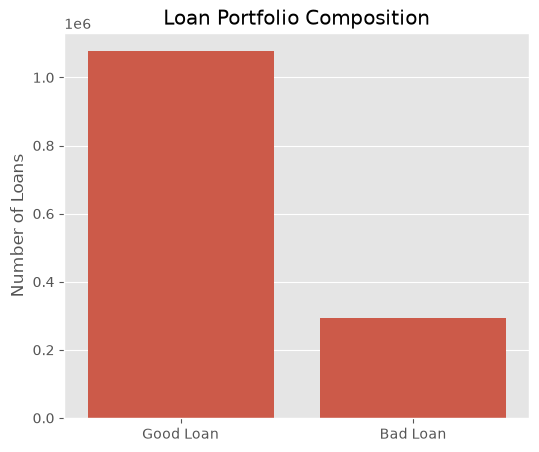

In [ ]:
# Visualize Portfolio composition

plt.figure(figsize=(6,5))

sns.countplot(
    data=loan_df,
    x="default_flag"
)

plt.xticks(
    [0,1],
    ["Good Loan","Bad Loan"]
)

plt.title("Loan Portfolio Composition")

plt.xlabel("")

plt.ylabel("Number of Loans")

plt.show()

In [49]:
# Default Rate by Percentage

loan_df["default_flag"].value_counts(normalize=True)*100

default_flag
0    78.528129
1    21.471871
Name: proportion, dtype: float64

Approximately 78% of loans were successfully repaid, while 22% resulted in default or severe delinquency. This indicates a moderately imbalanced dataset, which should be considered during model training using techniques such as class weighting or resampling.

STEP 7 : Loan Grade Analysis

Business Objective

Loan Grade is one of the strongest indicators of borrower creditworthiness.

Lenders assign grades (A–G) based on several factors such as:

Credit History
Income
FICO Score
Debt-to-Income Ratio
Repayment Behaviour

Typically,

Grade A → Lowest Risk
Grade G → Highest Risk

As a Credit Risk Analyst, we want to answer:

In [55]:
# STEP 7.1 : Loan Grade Distribution

grade_distribution = (
    loan_df["grade"]
    .value_counts()
    .sort_index()
    .reset_index()
)

grade_distribution.columns = [
    "Loan Grade",
    "Number of Loans"
]

grade_distribution

,Loan Grade,Number of Loans
0,A,236758
1,B,398529
2,C,390724
3,D,206696
4,E,96224
5,F,32828
6,G,9407


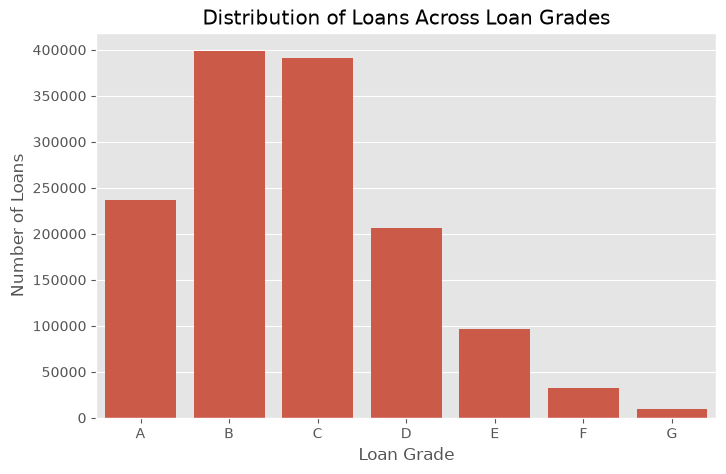

In [56]:
# Loan Grade Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    data=loan_df,
    x="grade",
    order=sorted(loan_df["grade"].unique())
)

plt.title("Distribution of Loans Across Loan Grades")

plt.xlabel("Loan Grade")

plt.ylabel("Number of Loans")

plt.show()

Interpretation

Look for:

Which grade has the largest number of loans? B
Which grades are least common? G

Example:

Most loans belong to Grade B and Grade C, indicating that the lender primarily serves medium-risk borrowers.

In [57]:
# STEP 7.2 : Default Rate by Loan Grade

grade_default = (
    loan_df
    .groupby("grade")
    .agg(
        Total_Loans=("default_flag", "count"),
        Defaulted_Loans=("default_flag", "sum")
    )
)

grade_default["Default Rate (%)"] = (
    grade_default["Defaulted_Loans"]
    / grade_default["Total_Loans"]
) * 100

grade_default = grade_default.reset_index()

grade_default

,grade,Total_Loans,Defaulted_Loans,Default Rate (%)
0,A,236758,15869,6.702625
1,B,398529,58357,14.643100
2,C,390724,94687,24.233730
3,D,206696,66797,32.316542
4,E,96224,38609,40.124085
5,F,32828,15261,46.487754
6,G,9407,4835,51.397895


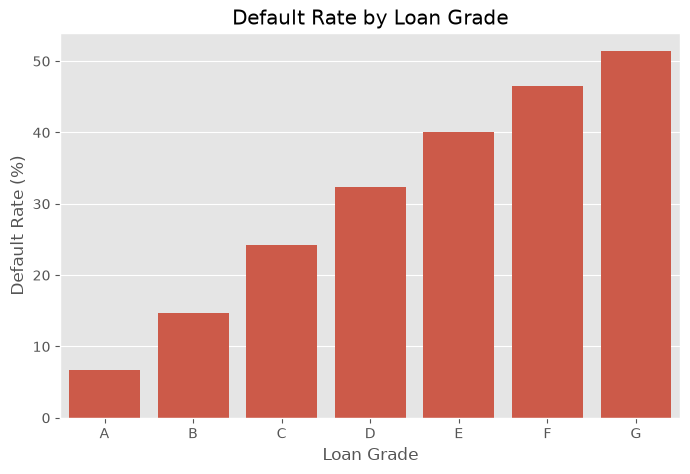

In [58]:
# STEP 7.3: Visualize Default Rate

plt.figure(figsize=(8,5))

sns.barplot(
    data=grade_default,
    x="grade",
    y="Default Rate (%)"
)

plt.title("Default Rate by Loan Grade")

plt.xlabel("Loan Grade")

plt.ylabel("Default Rate (%)")

plt.show()

Higher grade letter → Higher risk → Higher default rate.

In [ ]:
# STEP 7.4 : Average Interest Rate by Grade
# Are riskier borrowers charged higher interest rates?

interest_by_grade = (
    loan_df
    .groupby("grade")["int_rate"]
    .mean()
    .reset_index()
)

interest_by_grade

,grade,int_rate
0,A,7.113930
1,B,10.680002
2,C,14.029097
3,D,17.754606
4,E,21.206113
5,F,25.004516
6,G,27.796365


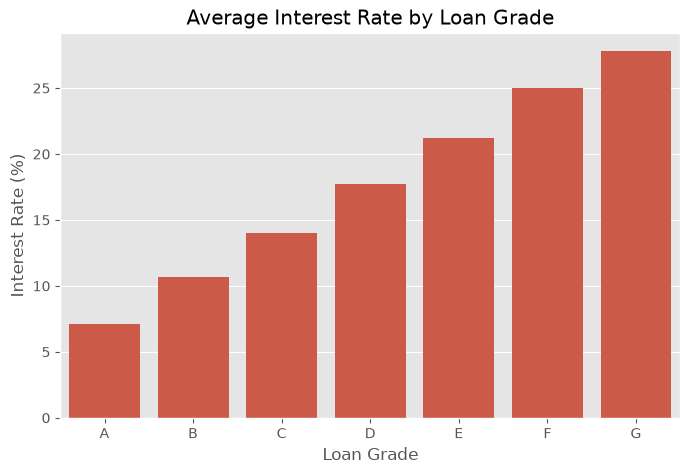

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=interest_by_grade,
    x="grade",
    y="int_rate"
)

plt.title("Average Interest Rate by Loan Grade")

plt.xlabel("Loan Grade")

plt.ylabel("Interest Rate (%)")

plt.show()

Business Insight

You should see:

Grade A → Lowest interest rate
Grade G → Highest interest rate

This demonstrates risk-based pricing, where borrowers with higher credit risk are charged higher interest rates to compensate for increased default risk.

In [61]:
# STEP 7.5 : Average Loan Amount by Grade
# Are larger loans issued to better-quality borrowers?

loan_amount_grade = (
    loan_df
    .groupby("grade")["loan_amnt"]
    .mean()
    .reset_index()
)

loan_amount_grade

,grade,loan_amnt
0,A,13908.030246
1,B,13276.814611
2,C,14252.589936
3,D,15327.977561
4,E,17633.276262
5,F,19117.348757
6,G,20613.495269


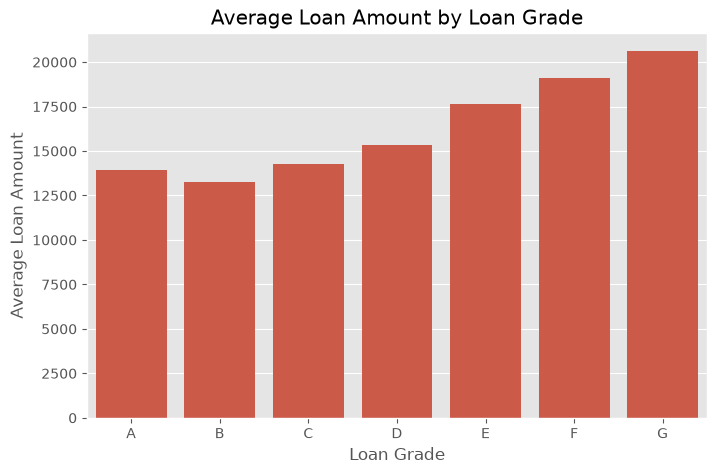

In [62]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=loan_amount_grade,
    x="grade",
    y="loan_amnt"
)

plt.title("Average Loan Amount by Loan Grade")

plt.xlabel("Loan Grade")

plt.ylabel("Average Loan Amount")

plt.show()

In [ ]:
# STEP 7.6: Summary Table
# Create a consolidated view 

grade_summary = (
    loan_df
    .groupby("grade")
    .agg(
        Total_Loans=("default_flag", "count"),
        Default_Rate=("default_flag", "mean"),
        Avg_Interest=("int_rate", "mean"),
        Avg_Loan=("loan_amnt", "mean"),
        Avg_Income=("annual_inc", "mean"),
        Avg_DTI=("dti", "mean")
    )
    .reset_index()
)

grade_summary["Default_Rate"] = grade_summary["Default_Rate"] * 100

grade_summary

,grade,Total_Loans,Default_Rate,Avg_Interest,Avg_Loan,Avg_Income,Avg_DTI
0,A,236758,6.702625,7.113930,13908.030246,88998.532602,15.622571
1,B,398529,14.643100,10.680002,13276.814611,76543.655788,17.394665
2,C,390724,24.233730,14.029097,14252.589936,72792.395656,18.938775
3,D,206696,32.316542,17.754606,15327.977561,70217.780246,20.218431
4,E,96224,40.124085,21.206113,17633.276262,72031.707966,20.890526
5,F,32828,46.487754,25.004516,19117.348757,73073.247085,21.047704
6,G,9407,51.397895,27.796365,20613.495269,76159.642153,21.562998


# Business Insights: Loan Grade Analysis

1. Loan Grades B and C represent the largest portion of the lending portfolio.

2. Default rates increase progressively from Grade A to Grade G, confirming that the grading system effectively captures borrower credit risk.

3. Higher-risk grades are associated with higher average interest rates, indicating the use of risk-based pricing strategies.

4. Borrowers in lower-risk grades generally exhibit stronger repayment performance, making them attractive targets for future lending.

5. The analysis validates that loan grade is one of the strongest predictors of loan default and should be included as a key feature in predictive modeling.

STEP 8 : SUB GRADE ANALYSIS

In [65]:
# STEP 8.1 : Distribution of Sub Grades

subgrade_distribution = (
    loan_df["sub_grade"]
    .value_counts()
    .sort_index()
    .reset_index()
)

subgrade_distribution.columns = [
    "Sub Grade",
    "Number of Loans"
]

subgrade_distribution

,Sub Grade,Number of Loans
0,A1,43866
1,A2,37419
2,A3,38297
3,A4,52665
4,A5,64511
5,B1,72022
6,B2,74959
7,B3,82875
8,B4,84533
9,B5,84140


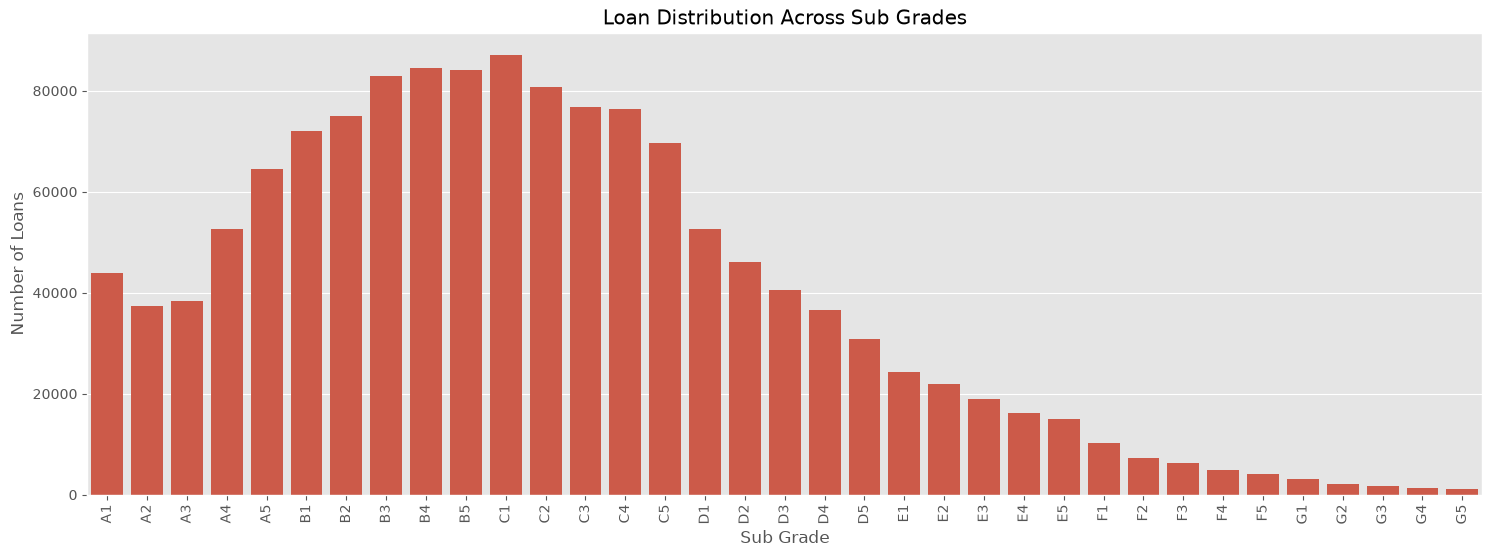

In [66]:
# Loan Distribution by Sub Grade

plt.figure(figsize=(18,6))

sns.countplot(
    data=loan_df,
    x="sub_grade",
    order=sorted(loan_df["sub_grade"].unique())
)

plt.title("Loan Distribution Across Sub Grades")

plt.xlabel("Sub Grade")

plt.ylabel("Number of Loans")

plt.xticks(rotation=90)

plt.show()

In [ ]:
# STEP 8.2 : Default Rate by Sub Grade
# Which sub grade and highest probability of default?

subgrade_default = (
    loan_df
    .groupby("sub_grade")
    .agg(
        Total_Loans=("default_flag", "count"),
        Defaulted_Loans=("default_flag", "sum")
    )
)

subgrade_default["Default Rate (%)"] = (
    subgrade_default["Defaulted_Loans"]
    / subgrade_default["Total_Loans"]
) * 100

subgrade_default = subgrade_default.reset_index()

subgrade_default

,sub_grade,Total_Loans,Defaulted_Loans,Default Rate (%)
0,A1,43866,1596,3.638353
1,A2,37419,1975,5.278067
2,A3,38297,2394,6.251142
3,A4,52665,4017,7.627457
4,A5,64511,5887,9.125575
5,B1,72022,8284,11.502041
6,B2,74959,9344,12.465481
7,B3,82875,11672,14.083861
8,B4,84533,13670,16.171199
9,B5,84140,15387,18.287378


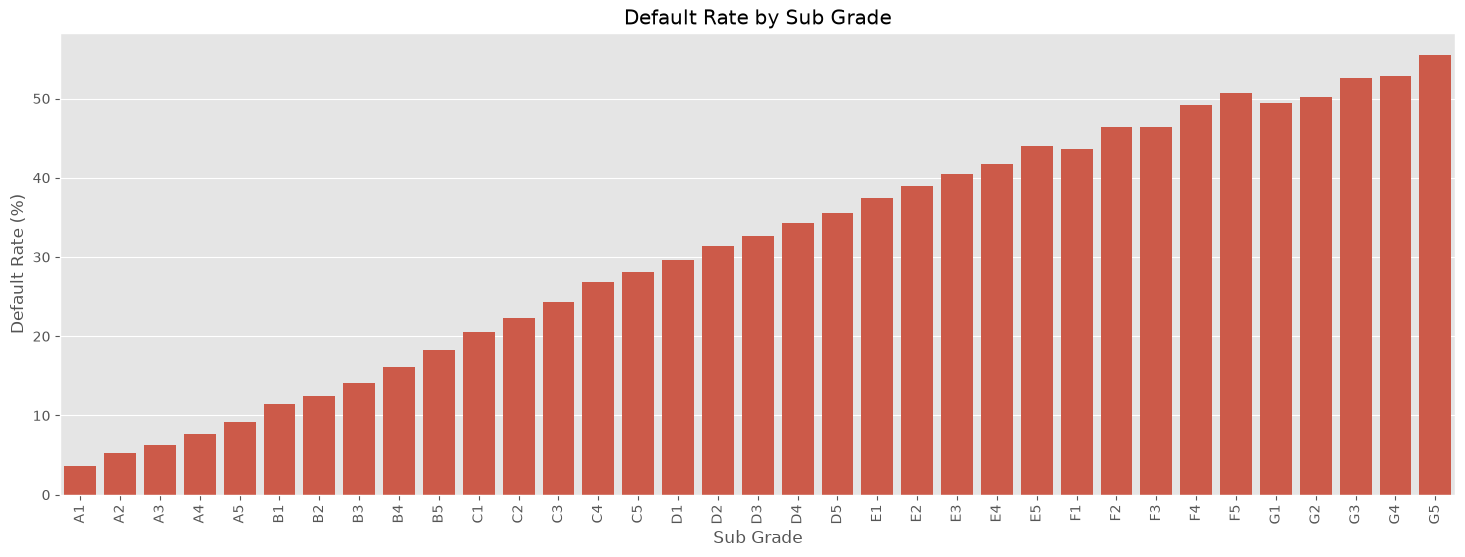

In [68]:
plt.figure(figsize=(18,6))

sns.barplot(
    data=subgrade_default,
    x="sub_grade",
    y="Default Rate (%)"
)

plt.title("Default Rate by Sub Grade")

plt.xlabel("Sub Grade")

plt.ylabel("Default Rate (%)")

plt.xticks(rotation=90)

plt.show()

In [70]:
# STEP 8.3 : Interest Rate by Sub Grade
# Do riskier sub grades receive higher interest rates?

interest_subgrade = (
    loan_df
    .groupby("sub_grade")["int_rate"]
    .mean()
    .reset_index()
)

interest_subgrade

,sub_grade,int_rate
0,A1,5.538272
1,A2,6.522450
2,A3,7.119047
3,A4,7.512957
4,A5,8.199631
5,B1,8.907779
6,B2,9.908031
7,B3,10.747137
8,B4,11.487758
9,B5,12.007067


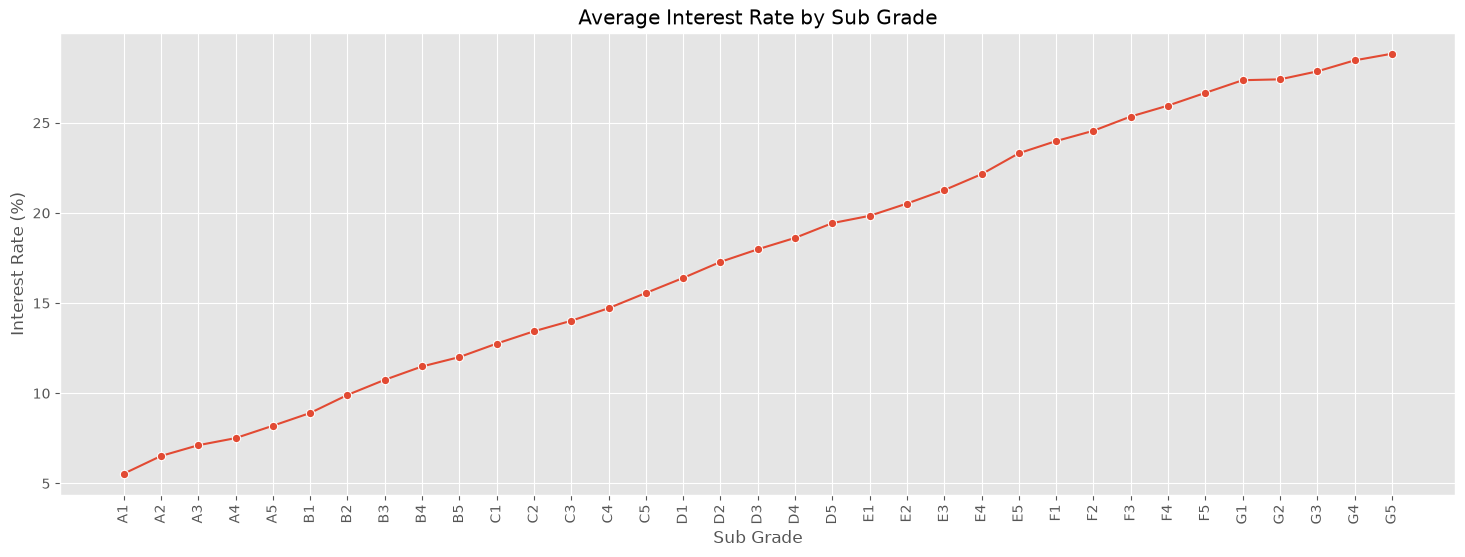

In [71]:
plt.figure(figsize=(18,6))

sns.lineplot(
    data=interest_subgrade,
    x="sub_grade",
    y="int_rate",
    marker="o"
)

plt.title("Average Interest Rate by Sub Grade")

plt.xlabel("Sub Grade")

plt.ylabel("Interest Rate (%)")

plt.xticks(rotation=90)

plt.show()

If interest rates increase from A1 to G5, it confirms that the institution uses risk-based pricing, where higher-risk borrowers pay higher interest rates.

In [73]:
# STEP 8.4 : Average Loan Amount by Sub Grade
# Do riskier borrowers receive smaller loan amounts?

loan_amount_subgrade = (
    loan_df
    .groupby("sub_grade")["loan_amnt"]
    .mean()
    .reset_index()
)

loan_amount_subgrade

,sub_grade,loan_amnt
0,A1,14035.518397
1,A2,13402.985115
2,A3,13630.310468
3,A4,14069.998576
4,A5,14146.929981
5,B1,13261.811322
6,B2,13351.764631
7,B3,13506.675716
8,B4,13315.039984
9,B5,12958.076123


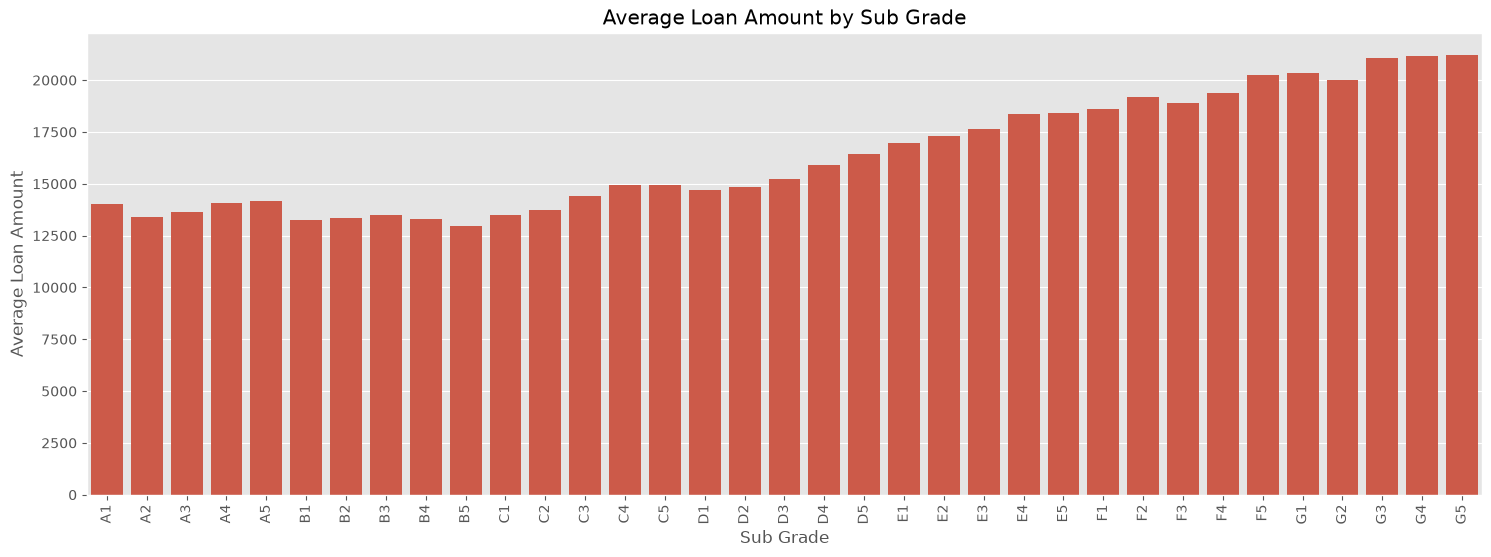

In [74]:
plt.figure(figsize=(18,6))

sns.barplot(
    data=loan_amount_subgrade,
    x="sub_grade",
    y="loan_amnt"
)

plt.title("Average Loan Amount by Sub Grade")

plt.xlabel("Sub Grade")

plt.ylabel("Average Loan Amount")

plt.xticks(rotation=90)

plt.show()

In [ ]:
# STEP 8.5 : Sub Grade Summary

subgrade_summary = (
    loan_df
    .groupby("sub_grade")
    .agg(
        Total_Loans=("default_flag", "count"),
        Default_Rate=("default_flag", "mean"),
        Avg_Interest=("int_rate", "mean"),
        Avg_Loan=("loan_amnt", "mean"),
        Avg_Income=("annual_inc", "mean"),
        Avg_DTI=("dti", "mean")
    )
    .reset_index()
)

subgrade_summary["Default_Rate"] *= 100

subgrade_summary

# Business Insights: Sub Grade Analysis

1. Default rates increase progressively from A1 to G5, validating the effectiveness of the lender's sub-grade classification.

2. Higher-risk sub grades are associated with higher interest rates, reflecting a risk-based pricing strategy.

3. Certain sub grades exhibit significantly higher default rates despite relatively similar loan amounts, suggesting borrower credit quality is a stronger predictor of default than loan size.

4. Sub grade provides finer risk segmentation than loan grade and should be retained as a key feature for predictive modeling.

# STEP 8.6: Grade × Sub Grade Risk Heatmap


In [75]:
# ============================================================
# STEP 8.6.1 : Default Rate by Grade and Sub Grade
# ============================================================

heatmap_df = (
    loan_df
    .groupby(["grade", "sub_grade"])["default_flag"]
    .mean()
    .reset_index()
)

# Convert to percentage
heatmap_df["default_flag"] *= 100

heatmap_df.head()

,grade,sub_grade,default_flag
0,A,A1,3.638353
1,A,A2,5.278067
2,A,A3,6.251142
3,A,A4,7.627457
4,A,A5,9.125575


In [76]:
# ============================================================
# STEP 8.6.2 : Create Pivot Table
# ============================================================

risk_matrix = heatmap_df.pivot(
    index="grade",
    columns="sub_grade",
    values="default_flag"
)

risk_matrix

sub_grade,A1,A2,A3,A4,A5,B1,B2,B3,B4,B5,C1,C2,C3,C4,C5,D1,D2,D3,D4,D5,E1,E2,E3,E4,E5,F1,F2,F3,F4,F5,G1,G2,G3,G4,G5
grade,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
A,3.638353,5.278067,6.251142,7.627457,9.125575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B,NaN,NaN,NaN,NaN,NaN,11.502041,12.465481,14.083861,16.171199,18.287378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.517764,22.321175,24.281991,26.889107,28.140812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.595637,31.385799,32.656836,34.275097,35.570948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.429431,38.919389,40.514147,41.747092,43.999733,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,43.631197,46.432462,46.350072,49.12598,50.737463,NaN,NaN,NaN,NaN,NaN
G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.43384,50.229568,52.567976,52.830189,55.52677


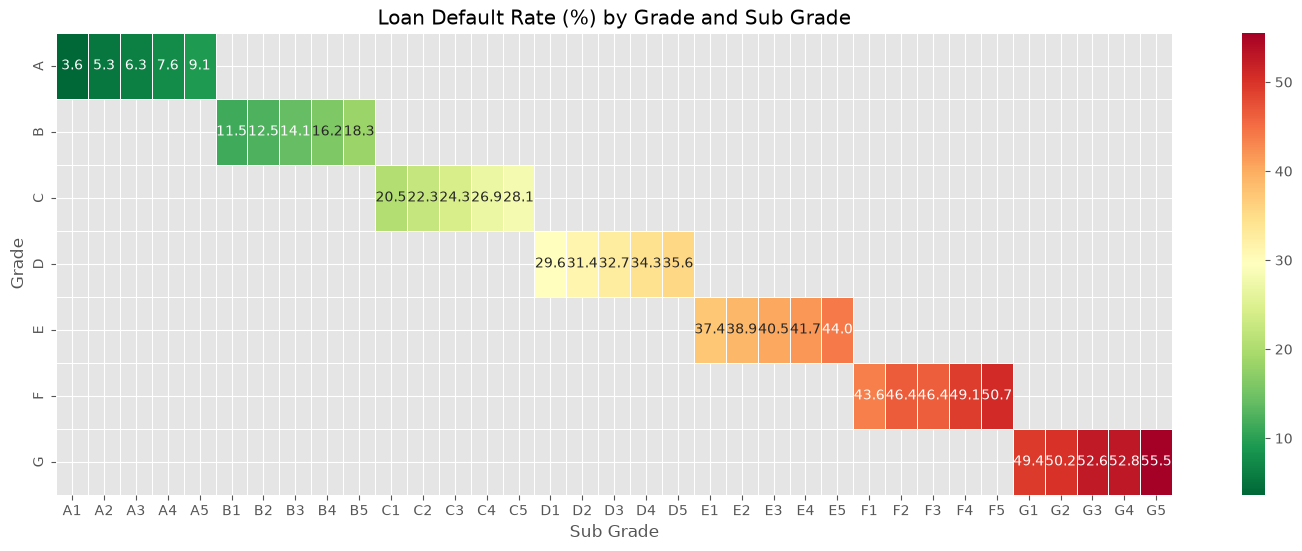

In [77]:
# ============================================================
# STEP 8.6.3 : Risk Heatmap
# ============================================================

plt.figure(figsize=(18,6))

sns.heatmap(
    risk_matrix,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5
)

plt.title("Loan Default Rate (%) by Grade and Sub Grade")

plt.xlabel("Sub Grade")

plt.ylabel("Grade")

plt.show()